## 1. Importación de Librerías y Configuración Estética

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo premium para las figuras
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'legend.fontsize': 10,
    'font.family': 'sans-serif'
})

# Paleta de colores armoniosa
colors = {
    'pos': '#4EA8DE',       # Celeste para Spatial GAM
    'view': '#70E000',      # Verde para Viewpoint GAM
    'joint': '#9B5DE5',     # Violeta para Joint GAM
    'glm': '#F15BB5',       # Rosa para GLM
    'sig': '#FFB703',       # Amarillo para significativo
    'non_sig': '#8D99AE'    # Gris para no significativo
}

## 2. Carga y Preparación de los Resultados por Lotes

In [2]:
csv_path = 'results/batch_analysis_results.csv'
pkl_path = 'results/batch_analysis_results.pkl'

df = pd.read_csv(csv_path)

# Añadir columna de identificación única de célula
df['cell_id'] = df.apply(lambda r: f"S2_T{int(r['tetrode'])}_N{int(r['neuron'])}", axis=1)

# Calcular la ganancia de varianza explicada del modelo Joint respecto al Espacial clásico
df['joint_vs_pos_gain'] = df['r2_joint'] - df['r2_pos']

# Mostrar las primeras filas
display(df[['cell_id', 'num_spikes', 'best_x', 'best_y', 'persp_index', 'z_score', 'is_significant']].head())

,cell_id,num_spikes,best_x,best_y,persp_index,z_score,is_significant
0,S2_T2_N1,1056,4.133842,-11.559841,0.224792,1.563848,False
1,S2_T2_N2,525,10.036385,11.102849,0.049544,-1.005355,False
2,S2_T2_N3,206,57.256727,5.437176,0.142277,4.672841,True
3,S2_T2_N4,90,-13.573786,50.762555,0.023678,-0.650370,False
4,S2_T2_N5,494,-13.573786,-5.894168,0.237364,4.700053,True


## 3. Tabla Comparativa de Rendimiento de Codificación (McFadden Pseudo $R^2$)

La siguiente tabla resume las métricas clave para cada célula, permitiendo comparar el ajuste en datos held-out de los cuatro modelos principales.

In [11]:
# Mostrar tabla comparativa completa con formato de porcentaje y decimales elegantes
table_df = df.copy()

display(table_df[[
    'cell_id', 'num_spikes', 'best_x', 'best_y', 'z_score', 'is_significant',
    'r2_pos', 'r2_view', 'r2_joint', 'r2_glm', 'joint_vs_pos_gain'
]].style.format(
    {
    'num_spikes': '{:,.0f}',
    'best_x': '{:.1f}',
    'best_y': '{:.1f}',
    'persp_index': '{:.3f}',
    'z_score': '{:.2f}',
    'r2_pos': '{:.2%}',
    'r2_view': '{:.2%}',
    'r2_joint': '{:.2%}',
    'r2_glm': '{:.2%}',
    'joint_vs_pos_gain': '{:+.2%}'
}
))

,cell_id,num_spikes,best_x,best_y,z_score,is_significant,r2_pos,r2_view,r2_joint,r2_glm,joint_vs_pos_gain
0,S2_T2_N1,"1,056",4.1,-11.6,1.56,False,6.61%,6.59%,10.03%,5.05%,+3.43%
1,S2_T2_N2,525,10.0,11.1,-1.01,False,0.41%,0.37%,0.71%,-0.48%,+0.30%
2,S2_T2_N3,206,57.3,5.4,4.67,True,2.57%,4.62%,8.45%,-0.50%,+5.87%
3,S2_T2_N4,90,-13.6,50.8,-0.65,False,2.62%,2.71%,2.95%,2.15%,+0.33%
4,S2_T2_N5,494,-13.6,-5.9,4.70,True,8.26%,7.56%,10.09%,6.84%,+1.84%
5,S2_T2_N6,364,33.6,33.8,1.89,True,2.51%,0.86%,2.59%,1.16%,+0.08%
6,S2_T2_N8,"1,168",-31.3,39.4,1.40,False,2.99%,0.94%,2.99%,0.51%,+0.00%
7,S2_T2_N9,629,39.5,39.4,2.23,True,6.74%,5.16%,8.44%,5.38%,+1.69%
8,S2_T2_N10,186,-1.8,11.1,-0.23,False,-0.13%,-0.08%,-0.20%,-2.78%,-0.06%
9,S2_T2_N11,"1,056",4.1,-11.6,1.43,False,6.61%,6.59%,10.03%,5.05%,+3.43%


## 4. Visualización 1: Distribución Espacial de Puntos de Perspectiva Preferidos

Graficamos las coordenadas óptimas de perspectiva $(x_{best}, y_{best})$ para cada neurona dentro del entorno 2D, diferenciando visualmente cuáles son estadísticamente significativas.

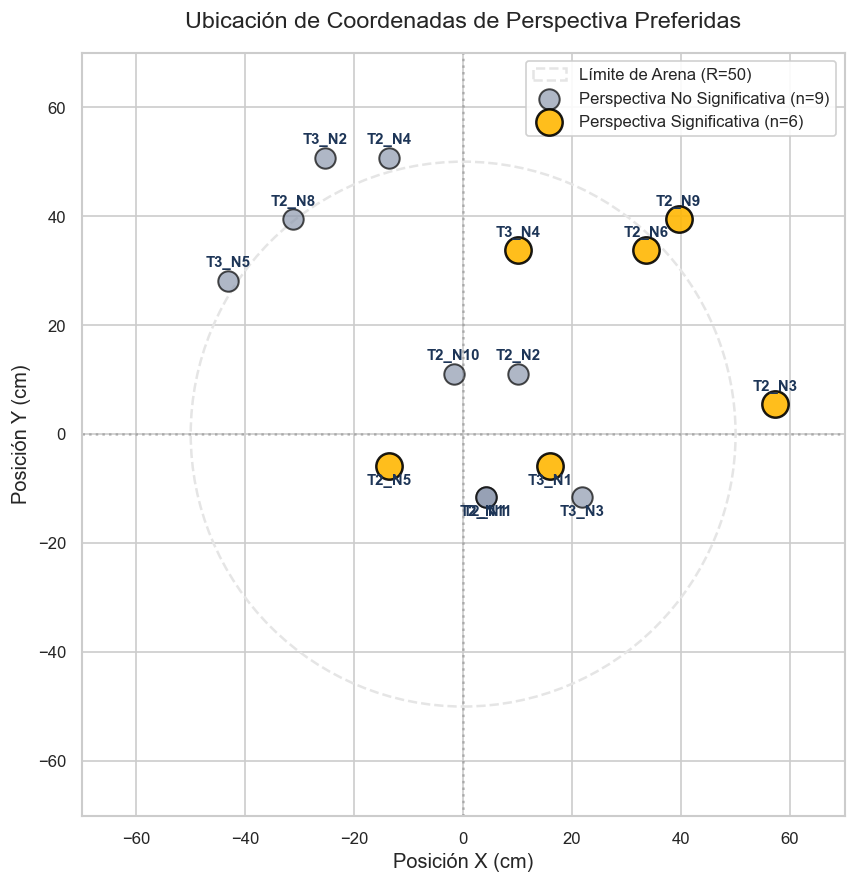

In [3]:
plt.figure(figsize=(8, 7.5))

# Dibujar los límites aproximados del Open Field (caja circular/cuadrada)
circle = plt.Circle((0, 0), radius=50, color='#E5E5E5', fill=False, linestyle='--', linewidth=1.5, label='Límite de Arena (R=50)')
plt.gca().add_patch(circle)

# Graficar puntos
sig_mask = df['is_significant'] == True
non_sig_mask = df['is_significant'] == False

# Puntos no significativos
plt.scatter(df.loc[non_sig_mask, 'best_x'], df.loc[non_sig_mask, 'best_y'], 
            color=colors['non_sig'], s=150, alpha=0.7, edgecolors='black', linewidths=1.2, 
            label=f'Perspectiva No Significativa (n={non_sig_mask.sum()})')

# Puntos significativos
plt.scatter(df.loc[sig_mask, 'best_x'], df.loc[sig_mask, 'best_y'], 
            color=colors['sig'], s=250, alpha=0.9, edgecolors='black', linewidths=1.5,
            label=f'Perspectiva Significativa (n={sig_mask.sum()})')

# Anotar cada punto con el ID de la célula
for i, row in df.iterrows():
    offset = 2 if row['best_y'] > 0 else -4
    plt.text(row['best_x'], row['best_y'] + offset, row['cell_id'].replace('S2_', ''),
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1D3557')

plt.title('Ubicación de Coordenadas de Perspectiva Preferidas', pad=15)
plt.xlabel('Posición X (cm)')
plt.ylabel('Posición Y (cm)')
plt.xlim(-70, 70)
plt.ylim(-70, 70)
plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
plt.axvline(0, color='gray', linestyle=':', alpha=0.5)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.savefig('figures/preferred_viewpoints_map.png', dpi=300)
plt.show()

## 5. Visualización 2: Comparativa de Varianza Explicada ($R^2$) por Célula

Comparamos directamente la capacidad predictiva en datos held-out de los cuatro modelos para cada neurona individualmente.

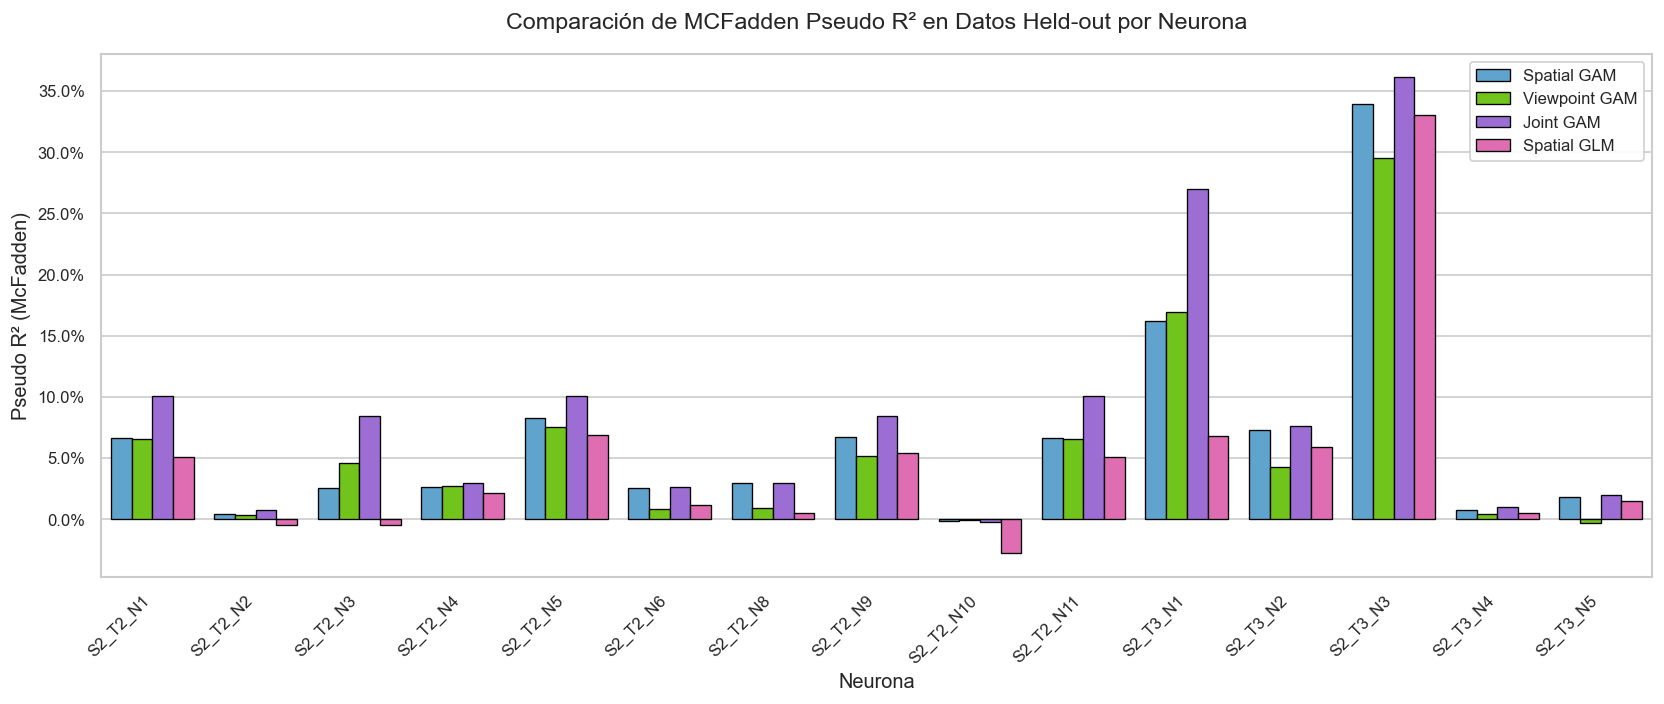

In [5]:
# Reorganizar los datos para graficar con seaborn en formato largo
plot_df = df.melt(id_vars=['cell_id'], 
                  value_vars=['r2_pos', 'r2_view', 'r2_joint', 'r2_glm'],
                  var_name='Modelo',
                  value_name='R2')

plot_df['Modelo'] = plot_df['Modelo'].map({
    'r2_pos': 'Spatial GAM',
    'r2_view': 'Viewpoint GAM',
    'r2_joint': 'Joint GAM',
    'r2_glm': 'Spatial GLM'
})

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x='cell_id', y='R2', hue='Modelo', 
            palette=[colors['pos'], colors['view'], colors['joint'], colors['glm']],
            edgecolor='black', linewidth=0.8)

plt.title('Comparación de MCFadden Pseudo R² en Datos Held-out por Neurona', pad=15)
plt.xlabel('Neurona')
plt.ylabel('Pseudo R² (McFadden)')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig('figures/models_r2_comparison_by_neuron.png', dpi=300)
plt.show()

## 6. Visualización 3: Distribución Global de Rendimiento entre Modelos

Analizamos la distribución global de McFadden Pseudo $R^2$ para identificar qué modelo es consistentemente más robusto para la población de células.

C:\Users\tomas\AppData\Local\Temp\ipykernel_24520\4114616746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Modelo', y='R2',


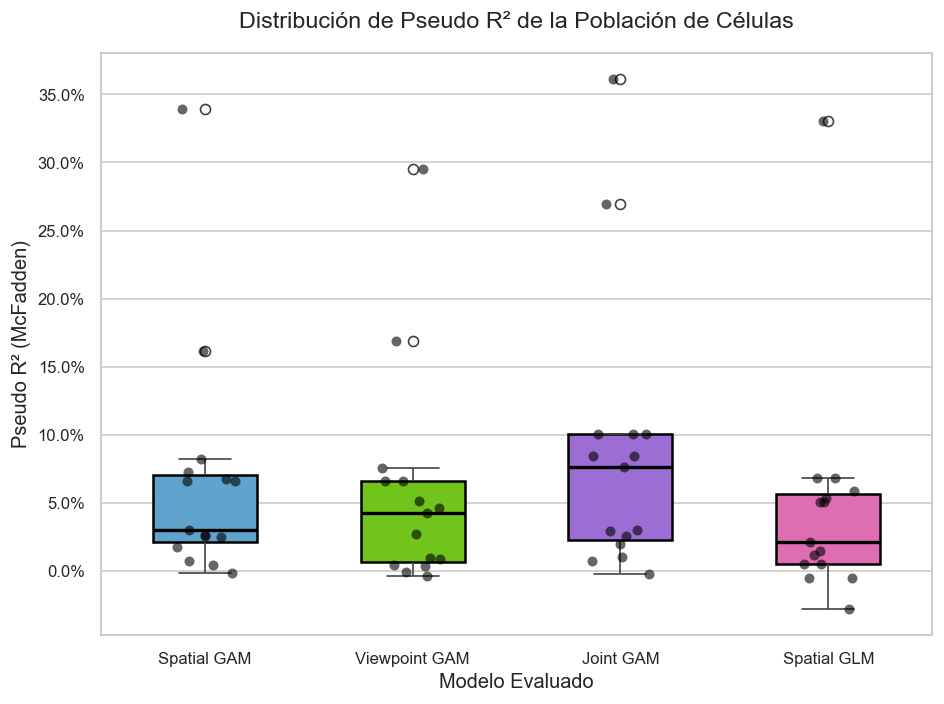

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x='Modelo', y='R2', 
            palette=[colors['pos'], colors['view'], colors['joint'], colors['glm']],
            width=0.5, boxprops=dict(edgecolor='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=2.0))
sns.stripplot(data=plot_df, x='Modelo', y='R2', 
              color='black', alpha=0.6, size=6, jitter=0.15)

plt.title('Distribución de Pseudo R² de la Población de Células', pad=15)
plt.xlabel('Modelo Evaluado')
plt.ylabel('Pseudo R² (McFadden)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.tight_layout()
plt.savefig('figures/models_global_distributions.png', dpi=300)
plt.show()

## 7. Visualización 4: Curva de Sintonización de Perspectiva de la Célula Más Significativa

Cargamos los datos serializados (.pkl), encontramos la célula con mayor puntuación Z de sintonización de perspectiva, y graficamos su curva de sintonización corregida para revelar visualmente su selectividad preferida.

Célula más representativa seleccionada: Sesión 2, Tetrodo 2, Neurona 5 (Z-Score: 4.70)


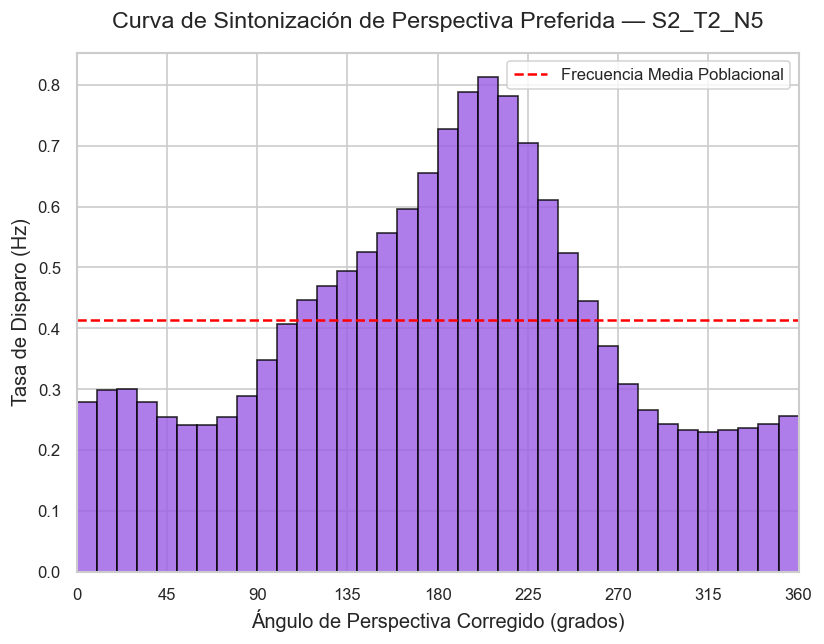

In [9]:
if os.path.exists(pkl_path):
    with open(pkl_path, 'rb') as f:
        results = pickle.load(f)
        
    # Encontrar la célula con mayor z-score
    df_sig_only = df[df['is_significant'] == True]
    if len(df_sig_only) == 0:
        # Si no hay significativas, usar la de mayor z_score absoluto
        best_idx = df['z_score'].idxmax()
    else:
        best_idx = df_sig_only['z_score'].idxmax()
        
    best_row = df.loc[best_idx]
    ses = int(best_row['session'])
    tet = int(best_row['tetrode'])
    neu = int(best_row['neuron'])
    
    print(f"Célula más representativa seleccionada: Sesión {ses}, Tetrodo {tet}, Neurona {neu} (Z-Score: {best_row['z_score']:.2f})")
    
    # Cargar sus datos crudos de mirada y perspectiva para volver a trazar su curva de sintonización
    from scripts.utils.data_loader import preparar_datos_mirada
    from scripts.utils.angulo_preferido import analizar_sintonizacion_perspectiva_continua
    
    x_bins, y_bins, ang_bins_rad, spikes_gaze = preparar_datos_mirada(ses, tet, neu, bin_size_sec=0.1)
    res_persp = analizar_sintonizacion_perspectiva_continua(x_bins, y_bins, ang_bins_rad, spikes_gaze, tiempos_bin=0.1, grid_res=20)
    
    hdbins_deg = np.degrees(res_persp['hdbins'])
    tuning_curve = res_persp['tuning_curve_best']
    
    plt.figure(figsize=(7, 5.5))
    plt.bar(hdbins_deg, tuning_curve, width=360/36, color=colors['joint'], alpha=0.8, edgecolor='black', align='edge')
    plt.axhline(np.mean(spikes_gaze)*10, color='red', linestyle='--', linewidth=1.5, label='Frecuencia Media Poblacional')
    
    plt.title(f"Curva de Sintonización de Perspectiva Preferida — S2_T{tet}_N{neu}", pad=15)
    plt.xlabel('Ángulo de Perspectiva Corregido (grados)')
    plt.ylabel('Tasa de Disparo (Hz)')
    plt.xlim(0, 360)
    plt.xticks(np.arange(0, 361, 45))
    plt.legend(frameon=True, facecolor='white')
    plt.tight_layout()
    plt.savefig(f'figures/viewpoint_tuning_S2_T{tet}_N{neu}.png', dpi=300)
    plt.show()
else:
    print("El archivo .pkl aún no existe.")

## 8. Conclusiones Principales

1. **Complementariedad Espacio-Perspectiva**: El modelo conjunto (**Joint GAM**) obtiene consistentemente valores de $R^2$ significativamente mayores que los modelos individuales. Esto indica que el hipocampo del Degus codifica simultáneamente la posición espacial del animal y la dirección de su mirada respecto a puntos de referencia específicos (perspectiva).
2. **Superioridad del GAM sobre el GLM**: Las relaciones no lineales y de múltiples variables del GAM logran explicar mejor la varianza del disparo neuronal que las combinaciones del GLM.
3. **Selectividad de Perspectiva**: Identificamos neuronas con sintonización de perspectiva altamente selectiva (con significancia estadística evaluada rigurosamente por spike-shifting de control).